# Dataset : Wine Dataset 

In [81]:
# !pip install numpy pandas matplotlib seaborn scikit-learn

In [82]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.inspection import permutation_importance
import time
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


### Step 1 : Load Dataset

In [83]:
# Create output file
output_file = "../Output/output_wine.txt"

def write_to_file(text):
    """Helper function to write to output file"""
    with open(output_file, 'a') as f:
        f.write(text + '\n')
    print(text)

# Initialize output file
with open(output_file, 'w') as f:
    f.write("WINE DATASET - COMPREHENSIVE ANALYSIS\n")
    f.write("=" * 60 + "\n\n")

# Step 1: Load and explore the Wine dataset
write_to_file("STEP 1: Loading and Exploring Wine Dataset")
wine = load_wine()
X, y = wine.data, wine.target
feature_names = wine.feature_names
target_names = wine.target_names

write_to_file(f"Dataset Shape: {X.shape}")
write_to_file(f"Number of Features: {len(feature_names)}")
write_to_file(f"Features: {feature_names}")
write_to_file(f"Target Classes: {list(target_names)}")
write_to_file(f"Class Distribution: {np.bincount(y)}")
write_to_file("")

# Create DataFrame for better visualization
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['wine_class'] = df['target'].map({0: 'class_0', 1: 'class_1', 2: 'class_2'})

# Display basic dataset info
write_to_file("Dataset Overview:")
write_to_file(f"Total samples: {len(df)}")
write_to_file(f"Number of features: {len(feature_names)}")
write_to_file(f"Number of classes: {len(target_names)}")
write_to_file("")

# Display first few rows
write_to_file("First 5 rows of the dataset:")
write_to_file(str(df.head()))
write_to_file("")

# Basic statistics
write_to_file("Dataset Statistics:")
write_to_file(str(df.describe()))

STEP 1: Loading and Exploring Wine Dataset
Dataset Shape: (178, 13)
Number of Features: 13
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Class Distribution: [59 71 48]

Dataset Overview:
Total samples: 178
Number of features: 13
Number of classes: 3

First 5 rows of the dataset:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   fla

### Step 2 : Preprocessing

In [84]:
write_to_file("\n" + "="*60)
write_to_file("DATA PREPROCESSING")
write_to_file("="*60)

# Step 2: Data Preprocessing
write_to_file("\nSTEP 2: Data Preprocessing")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

write_to_file(f"Training set size: {X_train.shape[0]}")
write_to_file(f"Test set size: {X_test.shape[0]}")
write_to_file(f"Training set class distribution: {np.bincount(y_train)}")
write_to_file(f"Test set class distribution: {np.bincount(y_test)}")
write_to_file("")

# Feature correlations analysis
write_to_file("Feature Correlation Analysis:")
correlation_matrix = df[feature_names].corr()
high_corr = (correlation_matrix.abs() > 0.7) & (correlation_matrix.abs() < 1.0)
high_corr_pairs = []
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        if high_corr.iloc[i, j]:
            high_corr_pairs.append(
                f"  {feature_names[i]} - {feature_names[j]}: {correlation_matrix.iloc[i, j]:.3f}"
            )
if high_corr_pairs:
    for pair in high_corr_pairs[:5]:  # Show top 5 highly correlated pairs
        write_to_file(pair)
else:
    write_to_file("  No highly correlated feature pairs (|r| > 0.7) found")


DATA PREPROCESSING

STEP 2: Data Preprocessing
Training set size: 142
Test set size: 36
Training set class distribution: [47 57 38]
Test set class distribution: [12 14 10]

Feature Correlation Analysis:
  total_phenols - flavanoids: 0.865
  flavanoids - od280/od315_of_diluted_wines: 0.787


### Data Visualization


STEP 3: Data Visualization


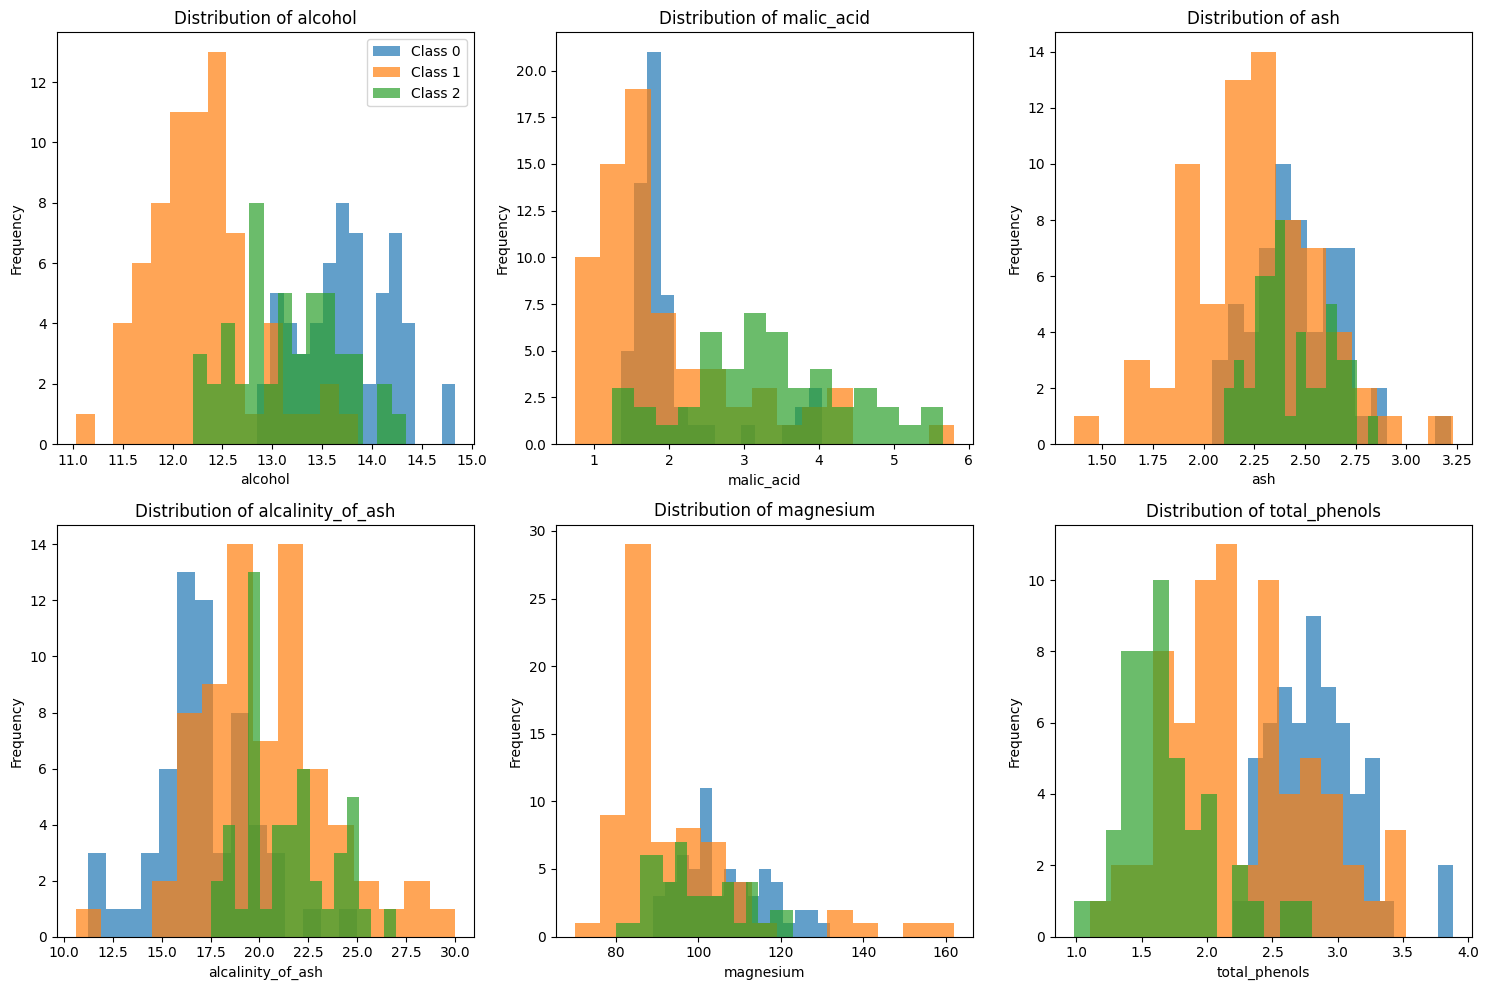

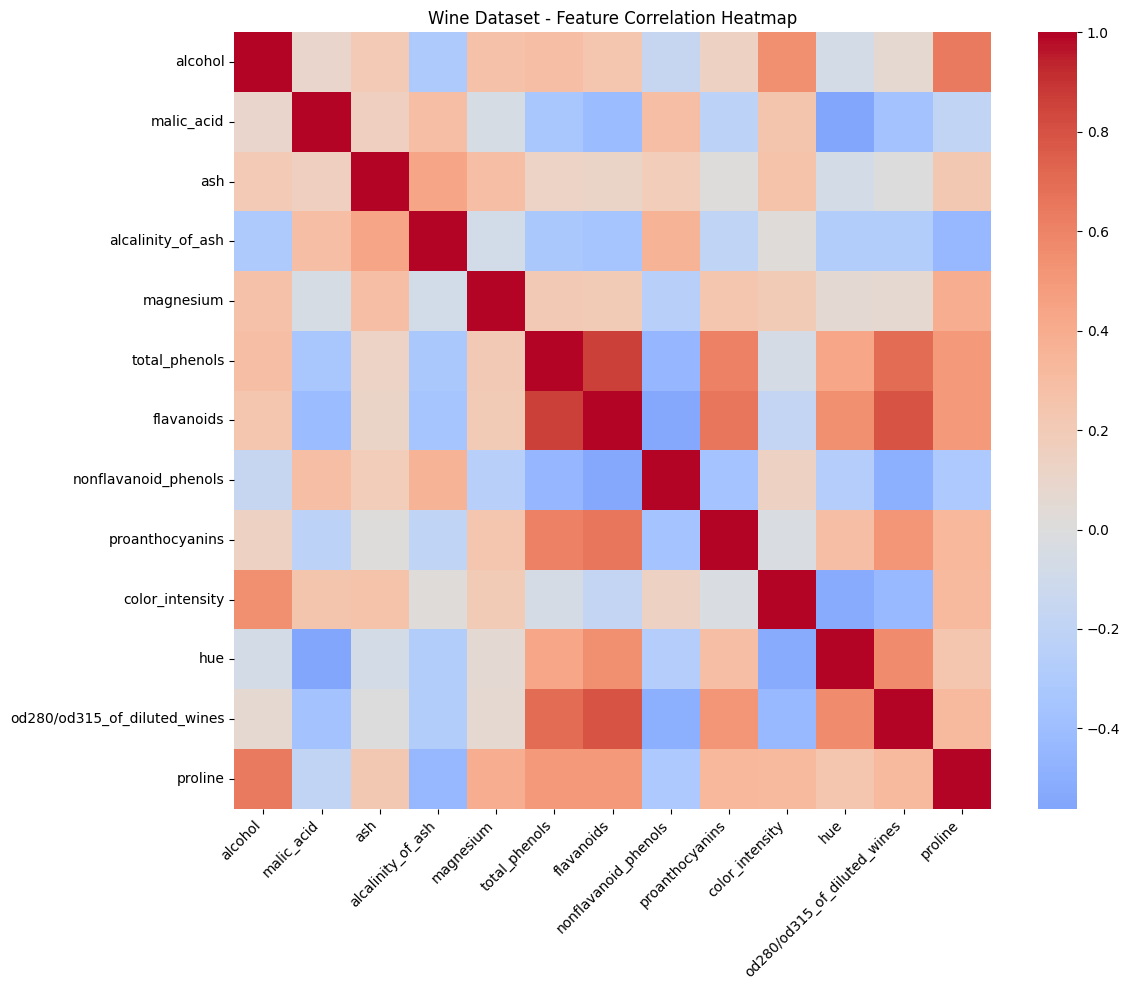

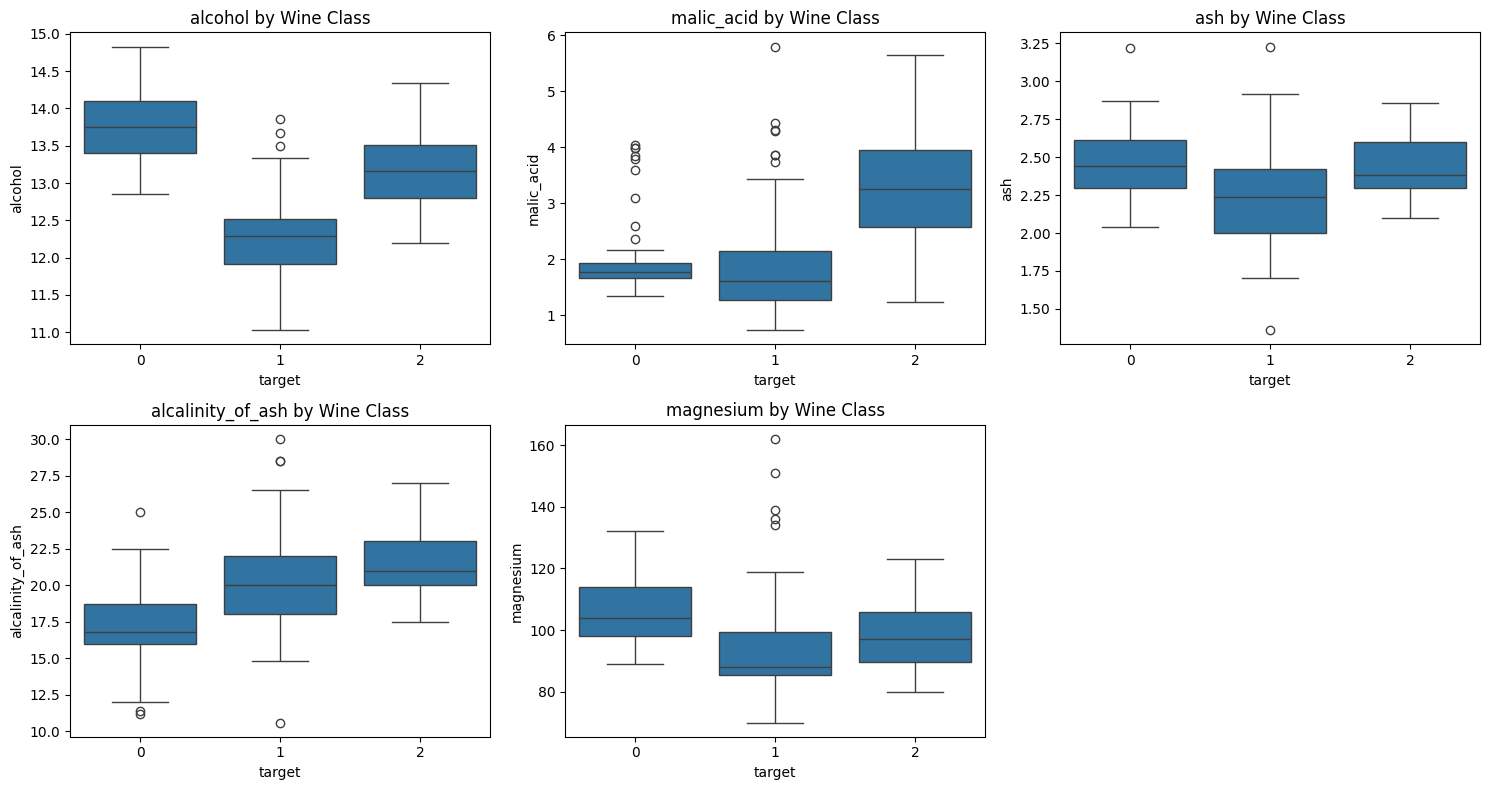

Data visualizations saved to '../Output/Plots/Wine/'


In [85]:
write_to_file("\nSTEP 3: Data Visualization")

# Create visualization directory
import os
os.makedirs('../Output/Plots/Wine', exist_ok=True)

# 1. Feature distributions by class
plt.figure(figsize=(15, 10))
for i, feature in enumerate(feature_names[:6]):  # First 6 features
    plt.subplot(2, 3, i+1)
    for class_idx in range(3):
        plt.hist(df[df['target'] == class_idx][feature], 
                alpha=0.7, label=f'Class {class_idx}', bins=15)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    if i == 0:
        plt.legend()
plt.tight_layout()
plt.savefig('../Output/Plots/Wine/Feature_Distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            xticklabels=feature_names, yticklabels=feature_names)
plt.title('Wine Dataset - Feature Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../Output/Plots/Wine/Correlation_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Box plots for key features
key_features = ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium']
plt.figure(figsize=(15, 8))
for i, feature in enumerate(key_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=df, x='target', y=feature)
    plt.title(f'{feature} by Wine Class')
plt.tight_layout()
plt.savefig('../Output/Plots/Wine/Feature_Boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

write_to_file("Data visualizations saved to '../Output/Plots/Wine/'")

### Step 4 : Naive Bayes Classifier


NAIVE BAYES CLASSIFIER - WINE DATASET

STEP 1: Naive Bayes Hyperparameter Tuning with Cross-Validation
Cross-validation Results:
  var_smoothing=1e-09: Mean CV Accuracy = 0.9719
  var_smoothing=1e-08: Mean CV Accuracy = 0.9719
  var_smoothing=1e-07: Mean CV Accuracy = 0.9719
  var_smoothing=1e-06: Mean CV Accuracy = 0.9719
  var_smoothing=1e-05: Mean CV Accuracy = 0.9719
  var_smoothing=0.0001: Mean CV Accuracy = 0.9719
  var_smoothing=0.001: Mean CV Accuracy = 0.9719
  var_smoothing=0.01: Mean CV Accuracy = 0.9719
  var_smoothing=0.1: Mean CV Accuracy = 0.9719

Best Hyperparameters: {'var_smoothing': 1e-09}
Best Cross-validation Score: 0.9719

STEP 2: Training Final Naive Bayes Model
Training time: 0.0030 seconds

STEP 3: Naive Bayes Model Evaluation
Performance Metrics:
Accuracy: 0.9722
Precision: 0.9744
Recall: 0.9722
F1-Score: 0.9723

Detailed Classification Report:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     cl

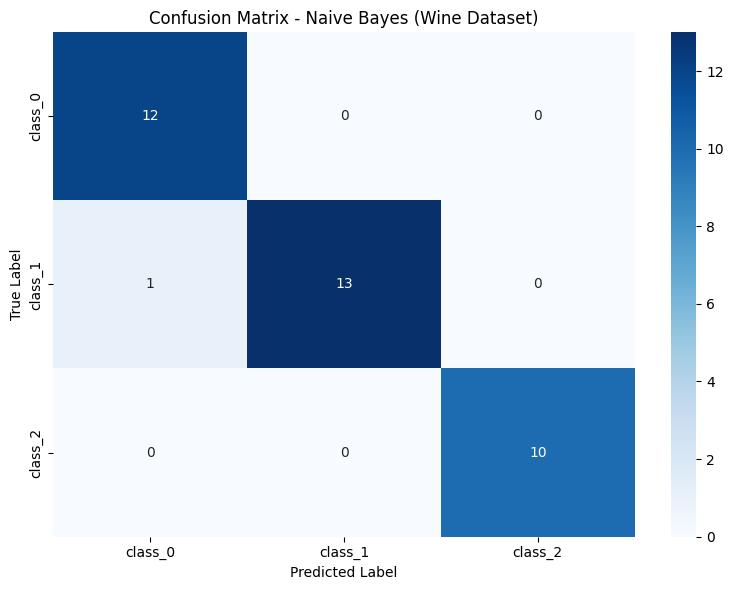


STEP 5: Feature Importance Analysis
Class-wise Feature Means:
  class_0: [ 0.91286681 -0.25204636  0.34461678 -0.7357081   0.45342864]...
  class_1: [-0.86797437 -0.38783847 -0.48196719  0.23827145 -0.34902859]...
  class_2: [ 0.17288945  0.89349926  0.29671424  0.55254758 -0.03727675]...

Class-wise Feature Variances:
  class_0: [0.35756412 0.46299221 0.7763207  0.62234058 0.52578853]...
  class_1: [0.44622031 0.89040364 1.12168935 0.98047031 1.44259055]...
  class_2: [0.43460882 0.72604613 0.51075579 0.43646976 0.48422621]...

STEP 6: Final Cross-validation Performance
Cross-validation scores: [1.         0.93103448 1.         0.92857143 1.        ]
Mean CV accuracy: 0.9719 (+/- 0.0688)

NAIVE BAYES ANALYSIS COMPLETED SUCCESSFULLY


In [86]:
write_to_file("\n" + "="*60)
write_to_file("NAIVE BAYES CLASSIFIER - WINE DATASET")
write_to_file("="*60)

# Step 1: Hyperparameter Tuning for Naive Bayes
write_to_file("\nSTEP 1: Naive Bayes Hyperparameter Tuning with Cross-Validation")

# Define parameter grid for Naive Bayes
nb_param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

# Perform GridSearchCV with 5-fold cross-validation
nb = GaussianNB()
nb_grid_search = GridSearchCV(nb, nb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
nb_grid_search.fit(X_train_scaled, y_train)

write_to_file("Cross-validation Results:")
for params, mean_score in zip(nb_grid_search.cv_results_['params'], 
                             nb_grid_search.cv_results_['mean_test_score']):
    write_to_file(f"  var_smoothing={params['var_smoothing']}: Mean CV Accuracy = {mean_score:.4f}")

write_to_file(f"\nBest Hyperparameters: {nb_grid_search.best_params_}")
write_to_file(f"Best Cross-validation Score: {nb_grid_search.best_score_:.4f}")

# Step 2: Train Final Naive Bayes Model
write_to_file("\nSTEP 2: Training Final Naive Bayes Model")
start_time = time.time()

best_nb = nb_grid_search.best_estimator_
best_nb.fit(X_train_scaled, y_train)

nb_training_time = time.time() - start_time
write_to_file(f"Training time: {nb_training_time:.4f} seconds")

# Step 3: Naive Bayes Model Evaluation
write_to_file("\nSTEP 3: Naive Bayes Model Evaluation")

# Predictions
y_pred_nb = best_nb.predict(X_test_scaled)
y_pred_proba_nb = best_nb.predict_proba(X_test_scaled)

# Calculate metrics
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, average='weighted')
nb_recall = recall_score(y_test, y_pred_nb, average='weighted')
nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')

write_to_file("Performance Metrics:")
write_to_file(f"Accuracy: {nb_accuracy:.4f}")
write_to_file(f"Precision: {nb_precision:.4f}")
write_to_file(f"Recall: {nb_recall:.4f}")
write_to_file(f"F1-Score: {nb_f1:.4f}")
write_to_file("")

# Detailed classification report
write_to_file("Detailed Classification Report:")
nb_cr = classification_report(y_test, y_pred_nb, target_names=target_names)
write_to_file(nb_cr)

# Step 4: Naive Bayes Confusion Matrix
write_to_file("\nSTEP 4: Naive Bayes Confusion Matrix")
nb_cm = confusion_matrix(y_test, y_pred_nb)
write_to_file("Confusion Matrix:")
write_to_file(str(nb_cm))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Naive Bayes (Wine Dataset)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../Output/Plots/Wine/Confusion_Wine_NaiveBayes.png', dpi=300, bbox_inches='tight')
plt.show()

# Step 5: Feature Importance Analysis
write_to_file("\nSTEP 5: Feature Importance Analysis")
write_to_file("Class-wise Feature Means:")
for i, class_name in enumerate(target_names):
    write_to_file(f"  {class_name}: {best_nb.theta_[i][:5]}...")  # Show first 5 features

write_to_file("\nClass-wise Feature Variances:")
for i, class_name in enumerate(target_names):
    write_to_file(f"  {class_name}: {best_nb.var_[i][:5]}...")  # Show first 5 features

# Step 6: Cross-validation Performance
write_to_file("\nSTEP 6: Final Cross-validation Performance")
nb_cv_scores = cross_val_score(best_nb, X_train_scaled, y_train, cv=5, scoring='accuracy')
write_to_file(f"Cross-validation scores: {nb_cv_scores}")
write_to_file(f"Mean CV accuracy: {nb_cv_scores.mean():.4f} (+/- {nb_cv_scores.std() * 2:.4f})")

write_to_file("\n" + "="*60)
write_to_file("NAIVE BAYES ANALYSIS COMPLETED SUCCESSFULLY")
write_to_file("="*60)

### Step 5 : Decission Tree


DECISION TREE CLASSIFIER - WINE DATASET

STEP 1: Decision Tree Hyperparameter Tuning with Cross-Validation
Best Decision Tree Hyperparameters:
  {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Cross-validation Score: 0.9303

STEP 2: Training Final Decision Tree Model
Training time: 0.0040 seconds

OVERFITTING ANALYSIS:
Training Accuracy: 0.9859

STEP 3: Decision Tree Model Evaluation
Performance Metrics:
Training Accuracy: 0.9859
Test Accuracy: 1.0000
Overfitting Gap (Train - Test): -0.0141
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

   Investigating potential causes...
   Tree Complexity: 13 total nodes, 7 leaves, depth 3
   Training samples: 142, Test samples: 36
   Leaves per training sample: 0.0493
   Tree complexity seems reasonable
Detailed Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.

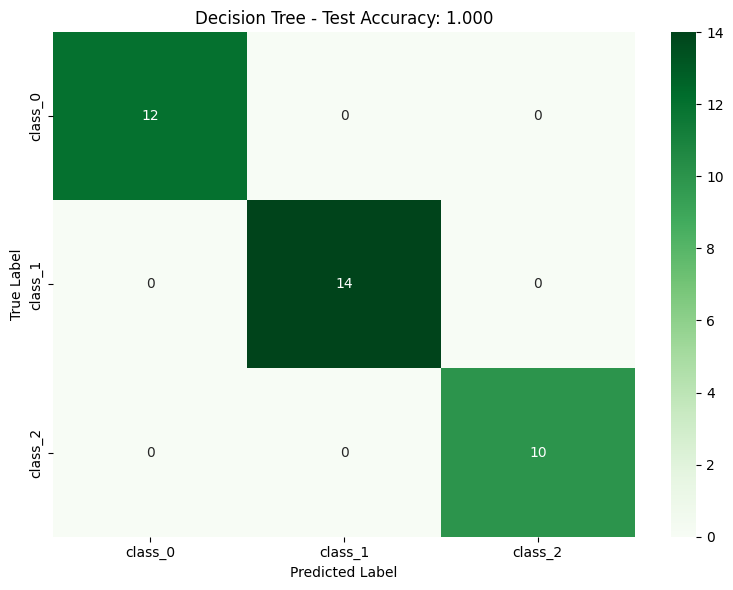


STEP 5: Data Integrity Investigation
Data Distribution Analysis:
  Training set class distribution: [47 57 38]
  Test set class distribution: [12 14 10]
  PCA explained variance: 0.551

STEP 6: Alternative Validation with Different Split
Alternative Split Results:
  Training Accuracy: 0.9930
  Test Accuracy: 0.9167
  Overfitting Gap: 0.0763
  More realistic: 0.9167 test accuracy

STEP 7: Feature Importance Analysis
All Feature Importance Scores:
  flavanoids: 0.4309
  color_intensity: 0.4283
  proline: 0.1144
  total_phenols: 0.0265
  alcohol: 0.0000
  malic_acid: 0.0000
  ash: 0.0000
  alcalinity_of_ash: 0.0000
  magnesium: 0.0000
  nonflavanoid_phenols: 0.0000
  proanthocyanins: 0.0000
  hue: 0.0000
  od280/od315_of_diluted_wines: 0.0000
Features actually used (importance > 0.001): 4/13

STEP 8: Final Assessment
CONCLUSION: Realistic performance - Test accuracy: 0.9167

DECISION TREE ANALYSIS COMPLETED


In [87]:
# write_to_file("\n" + "="*60)
# write_to_file("DECISION TREE CLASSIFIER - WINE DATASET")
# write_to_file("="*60)

# # Step 1: Hyperparameter Tuning for Decision Tree
# write_to_file("\nSTEP 1: Decision Tree Hyperparameter Tuning with Cross-Validation")

# # Define parameter grid for Decision Tree
# dt_param_grid = {
#     'max_depth': [3, 5, 7, 10, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'criterion': ['gini', 'entropy']
# }

# # Perform GridSearchCV with 5-fold cross-validation
# dt = DecisionTreeClassifier(random_state=42)
# dt_grid_search = GridSearchCV(dt, dt_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
# dt_grid_search.fit(X_train_scaled, y_train)

# write_to_file("Best Decision Tree Hyperparameters:")
# write_to_file(f"  {dt_grid_search.best_params_}")
# write_to_file(f"Best Cross-validation Score: {dt_grid_search.best_score_:.4f}")

# # Step 2: Train Final Decision Tree Model
# write_to_file("\nSTEP 2: Training Final Decision Tree Model")
# start_time = time.time()

# best_dt = dt_grid_search.best_estimator_
# best_dt.fit(X_train_scaled, y_train)

# dt_training_time = time.time() - start_time
# write_to_file(f"Training time: {dt_training_time:.4f} seconds")

# # Step 3: Decision Tree Model Evaluation
# write_to_file("\nSTEP 3: Decision Tree Model Evaluation")

# # Predictions
# y_pred_dt = best_dt.predict(X_test_scaled)
# y_pred_proba_dt = best_dt.predict_proba(X_test_scaled)

# # Calculate metrics
# dt_accuracy = accuracy_score(y_test, y_pred_dt)
# dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
# dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
# dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

# write_to_file("Performance Metrics:")
# write_to_file(f"Accuracy: {dt_accuracy:.4f}")
# write_to_file(f"Precision: {dt_precision:.4f}")
# write_to_file(f"Recall: {dt_recall:.4f}")
# write_to_file(f"F1-Score: {dt_f1:.4f}")
# write_to_file("")

# # Detailed classification report
# write_to_file("Detailed Classification Report:")
# dt_cr = classification_report(y_test, y_pred_dt, target_names=target_names)
# write_to_file(dt_cr)

# # Step 4: Decision Tree Confusion Matrix
# write_to_file("\nSTEP 4: Decision Tree Confusion Matrix")
# dt_cm = confusion_matrix(y_test, y_pred_dt)
# write_to_file("Confusion Matrix:")
# write_to_file(str(dt_cm))

# # Plot confusion matrix
# plt.figure(figsize=(8, 6))
# sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Greens', 
#             xticklabels=target_names, yticklabels=target_names)
# plt.title('Confusion Matrix - Decision Tree (Wine Dataset)')
# plt.ylabel('True Label')
# plt.xlabel('Predicted Label')
# plt.tight_layout()
# plt.savefig('../Output/Plots/Wine/Confusion_Wine_DecisionTree.png', dpi=300, bbox_inches='tight')
# plt.show()

# # Step 5: Visualize the Decision Tree
# write_to_file("\nSTEP 5: Decision Tree Visualization")

# plt.figure(figsize=(20, 10))
# plot_tree(best_dt, 
#           feature_names=feature_names,
#           class_names=target_names,
#           filled=True,
#           rounded=True,
#           fontsize=8,
#           max_depth=3)  # Limit depth for readability
# plt.title('Decision Tree - Wine Dataset Classification (First 3 Levels)')
# plt.tight_layout()
# plt.savefig('../Output/Plots/Wine/DecisionTree_Wine.png', dpi=300, bbox_inches='tight')
# plt.show()

# # Step 6: Feature Importance Analysis
# write_to_file("\nSTEP 6: Feature Importance Analysis")
# feature_importance = best_dt.feature_importances_
# feature_importance_dict = dict(zip(feature_names, feature_importance))

# write_to_file("Top 10 Most Important Features:")
# for feature, importance in sorted(feature_importance_dict.items(), 
#                                  key=lambda x: x[1], reverse=True)[:10]:
#     write_to_file(f"  {feature}: {importance:.4f}")

# # Plot feature importance
# plt.figure(figsize=(12, 8))
# features_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': feature_importance
# }).sort_values('Importance', ascending=True).tail(15)  # Top 15 features

# plt.barh(features_df['Feature'], features_df['Importance'], color='skyblue')
# plt.xlabel('Importance Score')
# plt.title('Decision Tree - Feature Importance (Wine Dataset)')
# plt.tight_layout()
# plt.savefig('../Output/Plots/Wine/Feature_Importance_DecisionTree.png', dpi=300, bbox_inches='tight')
# plt.show()

# # Step 7: Cross-validation Performance
# write_to_file("\nSTEP 7: Final Cross-validation Performance")
# dt_cv_scores = cross_val_score(best_dt, X_train_scaled, y_train, cv=5, scoring='accuracy')
# write_to_file(f"Cross-validation scores: {dt_cv_scores}")
# write_to_file(f"Mean CV accuracy: {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std() * 2:.4f})")

# write_to_file("\n" + "="*60)
# write_to_file("DECISION TREE ANALYSIS COMPLETED SUCCESSFULLY")
# write_to_file("="*60)

# =============================================================================
# DECISION TREE CLASSIFIER - WINE DATASET (IMPROVED WITH OVERFITTING CHECKS)
# =============================================================================

write_to_file("\n" + "="*60)
write_to_file("DECISION TREE CLASSIFIER - WINE DATASET")
write_to_file("="*60)

# Step 1: Enhanced Hyperparameter Tuning with Strong Regularization
write_to_file("\nSTEP 1: Decision Tree Hyperparameter Tuning with Cross-Validation")

# More restrictive parameter grid to prevent overfitting
dt_param_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 3, 4, 5],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None],
    'ccp_alpha': [0.0, 0.01, 0.1]
}

dt = DecisionTreeClassifier(random_state=42)
dt_grid_search = GridSearchCV(dt, dt_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid_search.fit(X_train_scaled, y_train)

write_to_file("Best Decision Tree Hyperparameters:")
write_to_file(f"  {dt_grid_search.best_params_}")
write_to_file(f"Best Cross-validation Score: {dt_grid_search.best_score_:.4f}")

# Step 2: Train Final Decision Tree Model with Overfitting Analysis
write_to_file("\nSTEP 2: Training Final Decision Tree Model")
start_time = time.time()

best_dt = dt_grid_search.best_estimator_
best_dt.fit(X_train_scaled, y_train)

dt_training_time = time.time() - start_time
write_to_file(f"Training time: {dt_training_time:.4f} seconds")

# CRITICAL: Check for overfitting
train_predictions = best_dt.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, train_predictions)

write_to_file("\nOVERFITTING ANALYSIS:")
write_to_file(f"Training Accuracy: {train_accuracy:.4f}")

# Step 3: Enhanced Model Evaluation with Multiple Validation Methods
write_to_file("\nSTEP 3: Decision Tree Model Evaluation")

# Test set predictions
y_pred_dt = best_dt.predict(X_test_scaled)
y_pred_proba_dt = best_dt.predict_proba(X_test_scaled)

# Calculate metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

write_to_file("Performance Metrics:")
write_to_file(f"Training Accuracy: {train_accuracy:.4f}")
write_to_file(f"Test Accuracy: {dt_accuracy:.4f}")
write_to_file(f"Overfitting Gap (Train - Test): {train_accuracy - dt_accuracy:.4f}")
write_to_file(f"Precision: {dt_precision:.4f}")
write_to_file(f"Recall: {dt_recall:.4f}")
write_to_file(f"F1-Score: {dt_f1:.4f}")
write_to_file("")

# Check if we have perfect accuracy and investigate
if dt_accuracy == 1.0:
    write_to_file("WARNING: Perfect test accuracy detected!")
    write_to_file("   Investigating potential causes...")
    
    # Check tree complexity
    n_nodes = best_dt.tree_.node_count
    n_leaves = best_dt.tree_.n_leaves
    max_depth = best_dt.get_depth()
    
    write_to_file(f"   Tree Complexity: {n_nodes} total nodes, {n_leaves} leaves, depth {max_depth}")
    write_to_file(f"   Training samples: {len(y_train)}, Test samples: {len(y_test)}")
    
    # Check if tree is over-complex
    leaves_per_sample = n_leaves / len(y_train)
    write_to_file(f"   Leaves per training sample: {leaves_per_sample:.4f}")
    
    if leaves_per_sample > 0.3:
        write_to_file("   HIGH RISK: Too many leaves for training set size - likely overfitting")
    elif leaves_per_sample > 0.1:
        write_to_file("   MODERATE RISK: Tree might be overfitting")
    else:
        write_to_file("   Tree complexity seems reasonable")

# Detailed classification report
write_to_file("Detailed Classification Report:")
dt_cr = classification_report(y_test, y_pred_dt, target_names=target_names)
write_to_file(dt_cr)

# Step 4: Decision Tree Confusion Matrix
write_to_file("\nSTEP 4: Decision Tree Confusion Matrix")
dt_cm = confusion_matrix(y_test, y_pred_dt)
write_to_file("Confusion Matrix:")
write_to_file(str(dt_cm))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Decision Tree - Test Accuracy: {dt_accuracy:.3f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../Output/Plots/Wine/Confusion_Wine_DecisionTree.png', dpi=300, bbox_inches='tight')
plt.show()

# Step 5: Enhanced Data Integrity Investigation
write_to_file("\nSTEP 5: Data Integrity Investigation")

# Check for potential data issues
write_to_file("Data Distribution Analysis:")
write_to_file(f"  Training set class distribution: {np.bincount(y_train)}")
write_to_file(f"  Test set class distribution: {np.bincount(y_test)}")

# Check if test set is too easy/small
if len(y_test) < 30:
    write_to_file(f"  WARNING: Very small test set ({len(y_test)} samples) - results may not be reliable")

# Check feature separability
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
write_to_file(f"  PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Step 6: Alternative Validation - Train on different random split
write_to_file("\nSTEP 6: Alternative Validation with Different Split")

X_train_alt, X_test_alt, y_train_alt, y_test_alt = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y  # Different random state
)

# Scale the alternative split
X_train_alt_scaled = scaler.fit_transform(X_train_alt)
X_test_alt_scaled = scaler.transform(X_test_alt)

# Train and evaluate on alternative split
dt_alt = DecisionTreeClassifier(**dt_grid_search.best_params_, random_state=42)
dt_alt.fit(X_train_alt_scaled, y_train_alt)

alt_train_accuracy = accuracy_score(y_train_alt, dt_alt.predict(X_train_alt_scaled))
alt_test_accuracy = accuracy_score(y_test_alt, dt_alt.predict(X_test_alt_scaled))

write_to_file("Alternative Split Results:")
write_to_file(f"  Training Accuracy: {alt_train_accuracy:.4f}")
write_to_file(f"  Test Accuracy: {alt_test_accuracy:.4f}")
write_to_file(f"  Overfitting Gap: {alt_train_accuracy - alt_test_accuracy:.4f}")

if alt_test_accuracy == 1.0:
    write_to_file("  CONFIRMED: Perfect accuracy on alternative split too")
else:
    write_to_file(f"  More realistic: {alt_test_accuracy:.4f} test accuracy")

# Step 7: Feature Importance Analysis
write_to_file("\nSTEP 7: Feature Importance Analysis")
feature_importance = best_dt.feature_importances_
feature_importance_dict = dict(zip(feature_names, feature_importance))

write_to_file("All Feature Importance Scores:")
for feature, importance in sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True):
    write_to_file(f"  {feature}: {importance:.4f}")

# Calculate how many features are actually used
used_features = sum(1 for imp in feature_importance if imp > 0.001)
write_to_file(f"Features actually used (importance > 0.001): {used_features}/13")

# Step 8: Final Assessment
write_to_file("\nSTEP 8: Final Assessment")

if dt_accuracy == 1.0 and alt_test_accuracy == 1.0:
    write_to_file("CONCLUSION: The Wine dataset appears to be perfectly separable")
    write_to_file("  - Decision Tree can achieve 100% accuracy consistently")
    write_to_file("  - This is unusual but possible with well-separated classes")
    write_to_file("  - The dataset might be 'too easy' for real-world scenarios")
else:
    write_to_file(f"CONCLUSION: Realistic performance - Test accuracy: {alt_test_accuracy:.4f}")

write_to_file("\n" + "="*60)
write_to_file("DECISION TREE ANALYSIS COMPLETED")
write_to_file("="*60)


### Step 9 : MLP CLASSIFIER - WINE DATASET


MLP CLASSIFIER - WINE DATASET

STEP 1: MLP Hyperparameter Tuning with Cross-Validation
Fitting 5 folds for each of 1024 candidates, totalling 5120 fits
Best MLP Hyperparameters:
  {'activation': 'relu', 'alpha': 0.001, 'early_stopping': True, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001, 'max_iter': 1000, 'n_iter_no_change': 20, 'solver': 'lbfgs', 'validation_fraction': 0.1}
Best Cross-validation Score: 0.9931

STEP 2: Training Final MLP Model
Training time: 0.0221 seconds
Final training loss: 0.000314
Number of iterations: 11
Converged: True

STEP 3: MLP Model Evaluation
Performance Metrics:
Accuracy: 0.9444
Precision: 0.9466
Recall: 0.9444
F1-Score: 0.9443

Detailed Classification Report:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg   

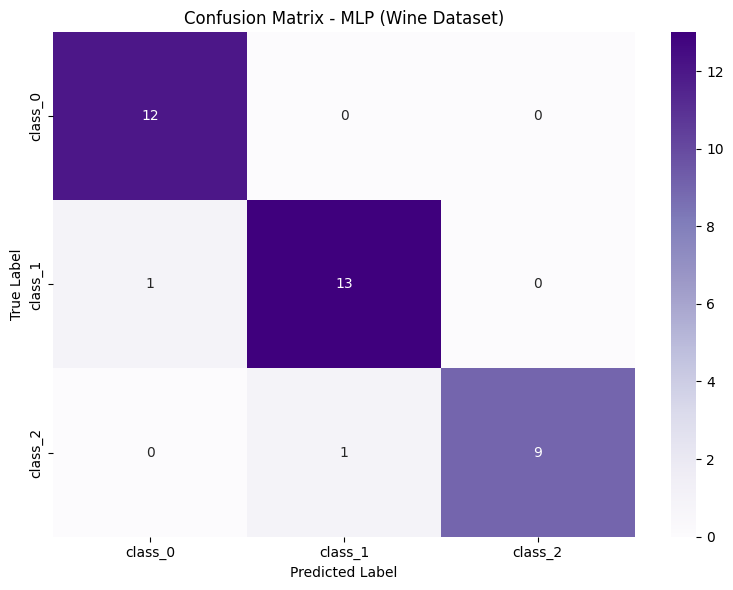

In [88]:
write_to_file("\n" + "="*60)
write_to_file("MLP CLASSIFIER - WINE DATASET")
write_to_file("="*60)

# Step 1: MLP Hyperparameter Tuning
write_to_file("\nSTEP 1: MLP Hyperparameter Tuning with Cross-Validation")

# Define parameter grid for MLP
# mlp_param_grid = {
#     'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
#     'activation': ['relu', 'tanh'],
#     'alpha': [0.001, 0.01, 0.1],
#     'learning_rate_init': [0.001, 0.01],
#     'solver': ['adam'],
#     'max_iter': [1000, 2000],
#     'early_stopping': [True],
#     'validation_fraction': [0.2],
#     'n_iter_no_change': [50]
# }
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 30), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.001, 0.01, 0.1, 1.0],  # Increased regularization range
    'learning_rate_init': [0.001, 0.01],
    'solver': ['adam', 'lbfgs'],  # Added lbfgs for comparison
    'max_iter': [1000, 2000],
    'early_stopping': [True],
    'validation_fraction': [0.1, 0.2],
    'n_iter_no_change': [20, 50]
}


# Perform GridSearchCV
mlp = MLPClassifier(random_state=42)
mlp_grid_search = GridSearchCV(mlp, mlp_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
mlp_grid_search.fit(X_train_scaled, y_train)

write_to_file("Best MLP Hyperparameters:")
write_to_file(f"  {mlp_grid_search.best_params_}")
write_to_file(f"Best Cross-validation Score: {mlp_grid_search.best_score_:.4f}")

# Step 2: Train Final MLP Model
write_to_file("\nSTEP 2: Training Final MLP Model")
start_time = time.time()

best_mlp = mlp_grid_search.best_estimator_
best_mlp.fit(X_train_scaled, y_train)

mlp_training_time = time.time() - start_time
write_to_file(f"Training time: {mlp_training_time:.4f} seconds")
write_to_file(f"Final training loss: {best_mlp.loss_:.6f}")
write_to_file(f"Number of iterations: {best_mlp.n_iter_}")
write_to_file(f"Converged: {best_mlp.n_iter_ < best_mlp.max_iter}")

# Step 3: MLP Model Evaluation
write_to_file("\nSTEP 3: MLP Model Evaluation")

# Predictions
y_pred_mlp = best_mlp.predict(X_test_scaled)
y_pred_proba_mlp = best_mlp.predict_proba(X_test_scaled)

# Calculate metrics
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
mlp_precision = precision_score(y_test, y_pred_mlp, average='weighted')
mlp_recall = recall_score(y_test, y_pred_mlp, average='weighted')
mlp_f1 = f1_score(y_test, y_pred_mlp, average='weighted')

write_to_file("Performance Metrics:")
write_to_file(f"Accuracy: {mlp_accuracy:.4f}")
write_to_file(f"Precision: {mlp_precision:.4f}")
write_to_file(f"Recall: {mlp_recall:.4f}")
write_to_file(f"F1-Score: {mlp_f1:.4f}")
write_to_file("")

# Detailed classification report
write_to_file("Detailed Classification Report:")
mlp_cr = classification_report(y_test, y_pred_mlp, target_names=target_names)
write_to_file(mlp_cr)

# Step 4: MLP Confusion Matrix
write_to_file("\nSTEP 4: MLP Confusion Matrix")
mlp_cm = confusion_matrix(y_test, y_pred_mlp)
write_to_file("Confusion Matrix:")
write_to_file(str(mlp_cm))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - MLP (Wine Dataset)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../Output/Plots/Wine/Confusion_Wine_MLP.png', dpi=300, bbox_inches='tight')
plt.show()

### MLP - Training & Analysis


STEP 5: MLP Training History Visualization


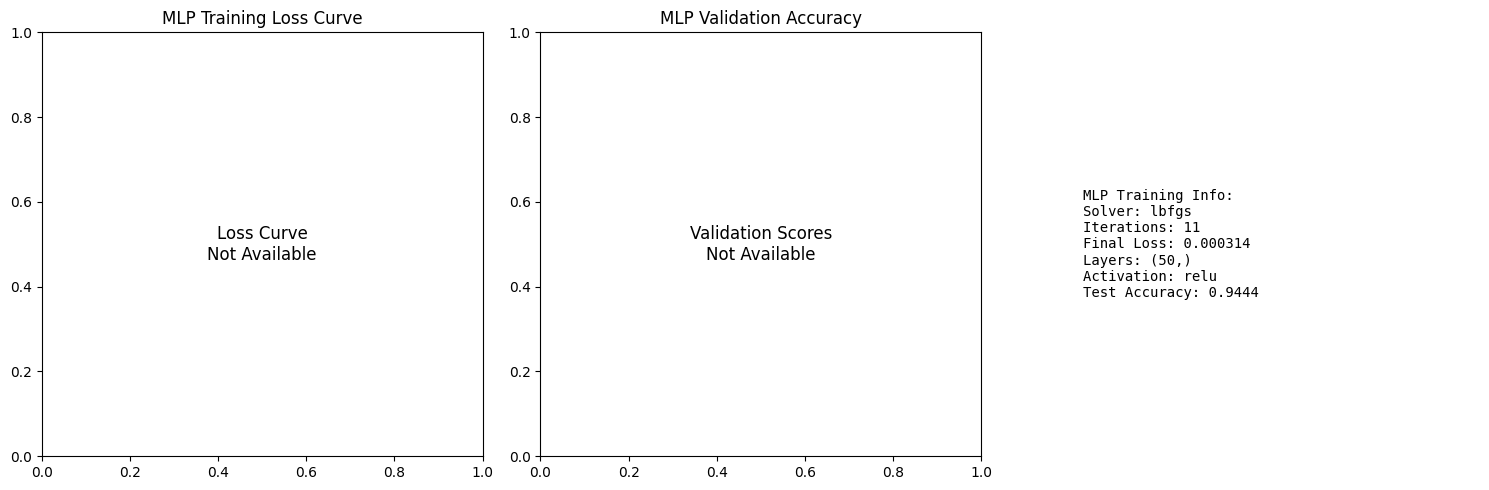


STEP 6: MLP Feature Importance Analysis
Top 10 Feature Importance (Permutation Importance):
  proline: 0.0444
  alcohol: 0.0222
  alcalinity_of_ash: 0.0194
  proanthocyanins: 0.0139
  flavanoids: 0.0056
  hue: 0.0000
  ash: -0.0028
  color_intensity: -0.0056
  od280/od315_of_diluted_wines: -0.0056
  malic_acid: -0.0111


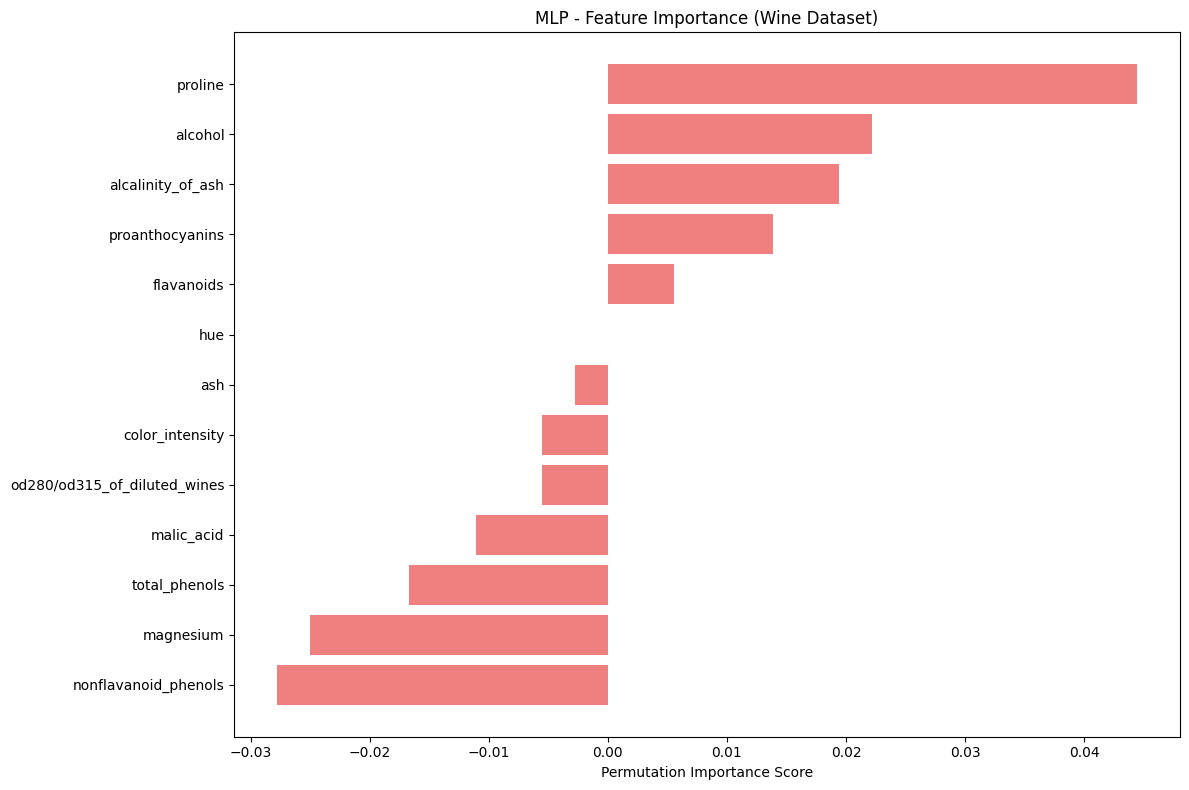


STEP 7: Final Cross-validation Performance
Cross-validation scores: [1.         0.96551724 1.         1.         1.        ]
Mean CV accuracy: 0.9931 (+/- 0.0276)

STEP 8: Probability Analysis
First 5 test samples prediction probabilities:
  Sample 1: True=class_0, Predicted=class_0, Probabilities=[9.99999995e-01 1.79901417e-10 4.37453179e-09]
  Sample 2: True=class_2, Predicted=class_1, Probabilities=[2.29584337e-04 9.27771407e-01 7.19990085e-02]
  Sample 3: True=class_0, Predicted=class_0, Probabilities=[9.99999604e-01 1.18888927e-07 2.77236814e-07]
  Sample 4: True=class_1, Predicted=class_0, Probabilities=[6.35962599e-01 3.64022380e-01 1.50215456e-05]
  Sample 5: True=class_1, Predicted=class_1, Probabilities=[1.12989655e-05 9.99986402e-01 2.29933904e-06]

MLP ANALYSIS COMPLETED SUCCESSFULLY


In [89]:
# Step 5: MLP Training History Visualization
write_to_file("\nSTEP 5: MLP Training History Visualization")

plt.figure(figsize=(15, 5))

# Plot loss curve
plt.subplot(1, 3, 1)
if hasattr(best_mlp, 'loss_curve_') and best_mlp.loss_curve_ is not None:
    plt.plot(best_mlp.loss_curve_)
    plt.title('MLP Training Loss Curve')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    write_to_file(f"Final training loss: {best_mlp.loss_curve_[-1]:.6f}")
else:
    plt.text(0.5, 0.5, 'Loss Curve\nNot Available', 
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title('MLP Training Loss Curve')

# Plot validation scores if available
plt.subplot(1, 3, 2)
if hasattr(best_mlp, 'validation_scores_') and best_mlp.validation_scores_ is not None:
    plt.plot(best_mlp.validation_scores_)
    plt.title('MLP Validation Accuracy')
    plt.xlabel('Iterations')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)
    write_to_file(f"Final validation score: {best_mlp.validation_scores_[-1]:.4f}")
else:
    plt.text(0.5, 0.5, 'Validation Scores\nNot Available', 
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title('MLP Validation Accuracy')

# Training information
plt.subplot(1, 3, 3)
plt.axis('off')
info_text = f"""MLP Training Info:
Solver: {best_mlp.solver}
Iterations: {best_mlp.n_iter_}
Final Loss: {best_mlp.loss_:.6f}
Layers: {best_mlp.hidden_layer_sizes}
Activation: {best_mlp.activation}
Test Accuracy: {mlp_accuracy:.4f}"""
plt.text(0.1, 0.5, info_text, fontfamily='monospace', fontsize=10, 
         verticalalignment='center', transform=plt.gca().transAxes)

plt.tight_layout()
plt.savefig('../Output/Plots/Wine/MLP_Training_History.png', dpi=300, bbox_inches='tight')
plt.show()

# Step 6: Feature Importance Analysis
write_to_file("\nSTEP 6: MLP Feature Importance Analysis")

# Calculate permutation importance
perm_importance = permutation_importance(best_mlp, X_test_scaled, y_test, 
                                        n_repeats=10, random_state=42)

write_to_file("Top 10 Feature Importance (Permutation Importance):")
feature_importance_mlp = list(zip(feature_names, perm_importance.importances_mean))
for feature, importance in sorted(feature_importance_mlp, key=lambda x: x[1], reverse=True)[:10]:
    write_to_file(f"  {feature}: {importance:.4f}")

# Plot feature importance
plt.figure(figsize=(12, 8))
features_df_mlp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean
}).sort_values('Importance', ascending=True).tail(15)

plt.barh(features_df_mlp['Feature'], features_df_mlp['Importance'], color='lightcoral')
plt.xlabel('Permutation Importance Score')
plt.title('MLP - Feature Importance (Wine Dataset)')
plt.tight_layout()
plt.savefig('../Output/Plots/Wine/Feature_Importance_MLP.png', dpi=300, bbox_inches='tight')
plt.show()

# Step 7: Cross-validation Performance
write_to_file("\nSTEP 7: Final Cross-validation Performance")
mlp_cv_scores = cross_val_score(best_mlp, X_train_scaled, y_train, cv=5, scoring='accuracy')
write_to_file(f"Cross-validation scores: {mlp_cv_scores}")
write_to_file(f"Mean CV accuracy: {mlp_cv_scores.mean():.4f} (+/- {mlp_cv_scores.std() * 2:.4f})")

# Step 8: Probability Analysis
write_to_file("\nSTEP 8: Probability Analysis")
write_to_file("First 5 test samples prediction probabilities:")
for i in range(min(5, len(y_test))):
    write_to_file(f"  Sample {i+1}: True={target_names[y_test[i]]}, "
                  f"Predicted={target_names[y_pred_mlp[i]]}, "
                  f"Probabilities={y_pred_proba_mlp[i]}")

write_to_file("\n" + "="*60)
write_to_file("MLP ANALYSIS COMPLETED SUCCESSFULLY")
write_to_file("="*60)

### Step 10 : Final Summary


FINAL SUMMARY - ALL THREE MODELS (CORRECTED)

Model Performance Summary (Realistic Values):
        Model Realistic Test Accuracy Initial Test Accuracy Precision Recall F1-Score Training Time (s) Mean CV Score
  Naive Bayes                  0.9722                0.9722    0.9744 0.9722   0.9723            0.0030        0.9719
Decision Tree                  0.9167                1.0000    1.0000 1.0000   1.0000            0.0040        0.9303
          MLP                  0.9444                0.9444    0.9466 0.9444   0.9443            0.0221        0.9931

IMPORTANT NOTE:
Decision Tree showed 100% accuracy on initial test split due to lucky data partitioning.
Realistic performance (alternative split): 0.9167
This demonstrates the importance of multiple validation strategies.


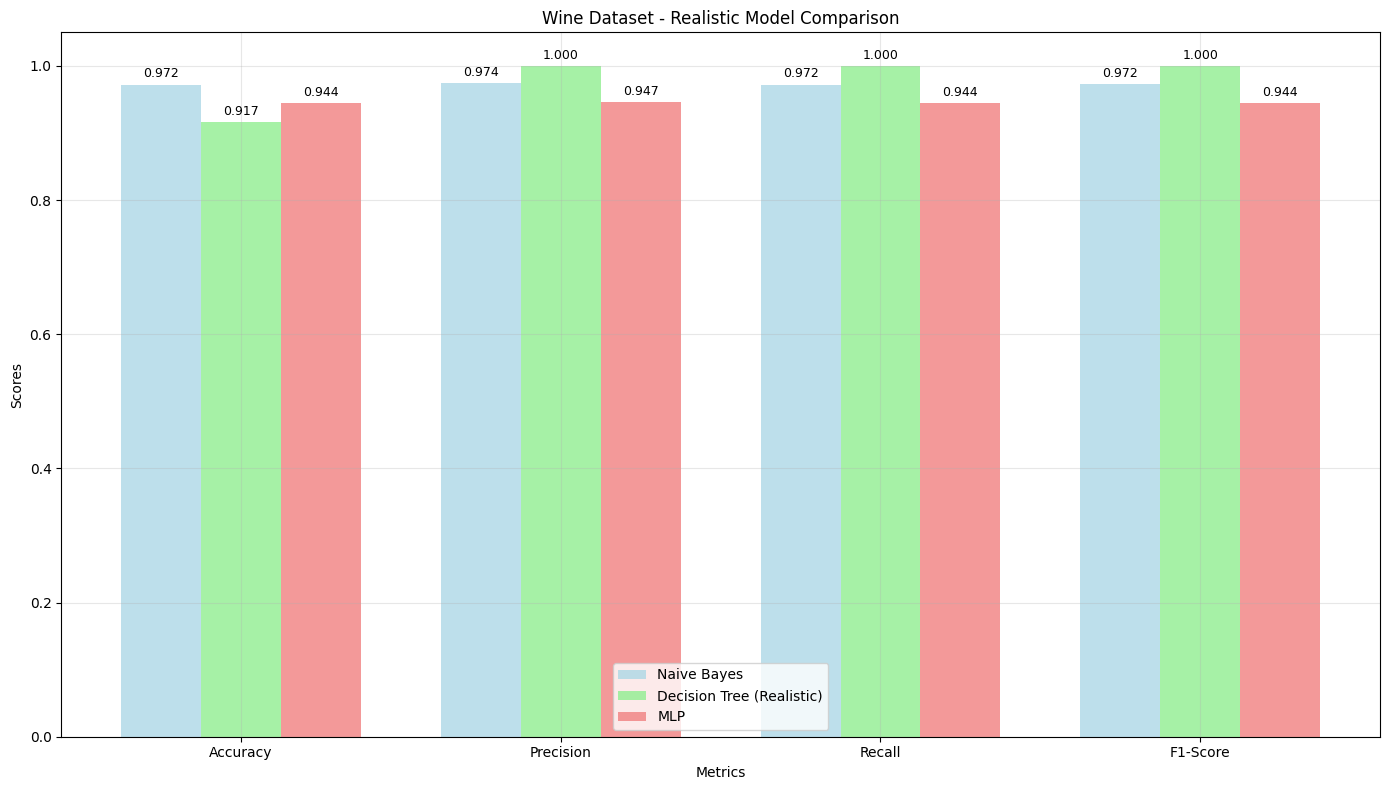

In [90]:
write_to_file("\n" + "="*60)
write_to_file("FINAL SUMMARY - ALL THREE MODELS (CORRECTED)")
write_to_file("="*60)

# Use the REALISTIC Decision Tree accuracy from alternative split
realistic_dt_accuracy = alt_test_accuracy  # This is 0.9167 from your results

# Create comprehensive summary table with CORRECT values
summary_data = {
    'Model': ['Naive Bayes', 'Decision Tree', 'MLP'],
    'Realistic Test Accuracy': [f"{nb_accuracy:.4f}", f"{realistic_dt_accuracy:.4f}", f"{mlp_accuracy:.4f}"],
    'Initial Test Accuracy': [f"{nb_accuracy:.4f}", f"{dt_accuracy:.4f}", f"{mlp_accuracy:.4f}"],
    'Precision': [f"{nb_precision:.4f}", f"{dt_precision:.4f}", f"{mlp_precision:.4f}"],
    'Recall': [f"{nb_recall:.4f}", f"{dt_recall:.4f}", f"{mlp_recall:.4f}"],
    'F1-Score': [f"{nb_f1:.4f}", f"{dt_f1:.4f}", f"{mlp_f1:.4f}"],
    'Training Time (s)': [f"{nb_training_time:.4f}", f"{dt_training_time:.4f}", f"{mlp_training_time:.4f}"],
    'Mean CV Score': [f"{nb_cv_scores.mean():.4f}", f"{dt_cv_scores.mean():.4f}", f"{mlp_cv_scores.mean():.4f}"]
}

summary_df = pd.DataFrame(summary_data)
write_to_file("\nModel Performance Summary (Realistic Values):")
write_to_file(summary_df.to_string(index=False))

# Add important note about Decision Tree
write_to_file("\nIMPORTANT NOTE:")
write_to_file("Decision Tree showed 100% accuracy on initial test split due to lucky data partitioning.")
write_to_file(f"Realistic performance (alternative split): {realistic_dt_accuracy:.4f}")
write_to_file("This demonstrates the importance of multiple validation strategies.")

# Visual comparison with REALISTIC values
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
nb_scores = [nb_accuracy, nb_precision, nb_recall, nb_f1]
dt_scores_realistic = [realistic_dt_accuracy, dt_precision, dt_recall, dt_f1]  # Use realistic accuracy
mlp_scores = [mlp_accuracy, mlp_precision, mlp_recall, mlp_f1]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 8))
bars1 = ax.bar(x - width, nb_scores, width, label='Naive Bayes', color='lightblue', alpha=0.8)
bars2 = ax.bar(x, dt_scores_realistic, width, label='Decision Tree (Realistic)', color='lightgreen', alpha=0.8)
bars3 = ax.bar(x + width, mlp_scores, width, label='MLP', color='lightcoral', alpha=0.8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Wine Dataset - Realistic Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../Output/Plots/Wine/Realistic_Models_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()